In [1]:
import pandas as pd
from pathlib import Path
import os
import plotly.express as px

os.chdir(Path.cwd().parent)

save_path= "backtest/attachments"

horizons = [1,3,5]
strategies = {"momentum_score": "Momentum Strategie", "value_score": "Value Strategie", "passive_GSPC": "Passive GSPC Strategie", "passive_SPXEW": "Passive SPXEW Strategie"}

df_strategies = pd.read_csv("backtest/data/backtest_data.csv")
df_benchmark_raw = pd.read_csv("backtest/data/benchmark_data.csv")

In [2]:
df_strategies_grouped = df_strategies.drop(labels=["sector"], axis=1).groupby(by=["buyyear", "sellyear","strategy"], as_index=False).median()
df_strategies_grouped["horizon"] = df_strategies_grouped["sellyear"] - df_strategies_grouped["buyyear"]
df_strategies_grouped = df_strategies_grouped[df_strategies_grouped["horizon"].isin(horizons)]
df_strategies_grouped = df_strategies_grouped.drop(axis=1, labels=["buyyear", "sellyear"])
df_strategies_grouped

,strategy,rendite,horizon
0,momentum_score,17.490,1
1,value_score,31.995,1
4,momentum_score,15.700,3
5,value_score,19.310,3
8,momentum_score,16.955,5
...,...,...,...
299,value_score,11.040,3
300,momentum_score,26.265,1
301,value_score,6.630,1
304,momentum_score,17.110,1


In [3]:
df_benchmark_raw["horizon"] = df_benchmark_raw["sellyear"] - df_benchmark_raw["buyyear"]
df_benchmark = df_benchmark_raw[df_benchmark_raw["horizon"].isin(horizons)]
df_benchmark = df_benchmark.drop(axis=1, labels=["index", "buyyear", "sellyear"])
df_benchmark

,rendite,strategy,horizon
0,43.26,passive_SPXEW,1
2,18.96,passive_SPXEW,3
4,20.99,passive_SPXEW,5
17,19.81,passive_SPXEW,1
19,10.65,passive_SPXEW,3
...,...,...,...
298,7.26,passive_GSPC,3
300,24.23,passive_GSPC,1
302,21.26,passive_GSPC,3
303,23.31,passive_GSPC,1


In [4]:
df_unified = pd.concat([df_strategies_grouped, df_benchmark]).reset_index(drop=True)
df_unified

,strategy,rendite,horizon
0,momentum_score,17.490,1
1,value_score,31.995,1
2,momentum_score,15.700,3
3,value_score,19.310,3
4,momentum_score,16.955,5
...,...,...,...
175,passive_GSPC,7.260,3
176,passive_GSPC,24.230,1
177,passive_GSPC,21.260,3
178,passive_GSPC,23.310,1


In [5]:
FONT = dict(family="Latin Modern Roman, Times New Roman, serif", size=14, color="#222222")

BLUE = "#4E79A7"        # Value
ORANGE = "#F28E2B"      # Momentum
GREY = "#949494"        # Benchmark GSPC
GREY_DARK = "#5c5c5c"   # Benchmark SPXEW (dunkler, damit beide Benchmarks unterscheidbar sind)

color_map = {
    "value_score": BLUE,
    "momentum_score": ORANGE,
    "passive_GSPC": GREY,
    "passive_SPXEW": GREY_DARK,
}
label_map = {
    "value_score": "Value",
    "momentum_score": "Momentum",
    "passive_GSPC": "Benchmark (S&P 500)",
    "passive_SPXEW": "Benchmark (SPXEW)",
}
order = ["Value", "Momentum", "Benchmark (S&P 500)", "Benchmark (SPXEW)"]

for h in horizons:

    df_filtered = df_unified[df_unified["horizon"] == h].copy()
    df_filtered["strategy_label"] = df_filtered["strategy"].map(label_map)

    fig = px.box(
        df_filtered,
        x="strategy_label",
        y="rendite",
        color="strategy",
        color_discrete_map=color_map,
        category_orders={"strategy_label": order},
        points="all",
    )

    fig.update_traces(
        marker=dict(size=6, opacity=0.6, line=dict(width=0.5, color="white")),
        line=dict(width=1.3),
        jitter=0.3,
        pointpos=0,
        width=0.5,             # <-- feste Boxbreite statt automatischer Vollbreite
    )

    fig.update_xaxes(
        title="Strategie",
        showline=True,
        linecolor="#333333",
        ticks="outside",
        tickangle=-15,          # bei 4 Kategorien mit längeren Labels leicht kippen
        automargin=True,
    )

    fig.update_yaxes(
        title="Rendite p.a. (%)",
        showline=True,
        linecolor="#333333",
        ticks="outside",
        gridcolor="#e6e6e6",
        zeroline=True,
        zerolinecolor="#333333",
        zerolinewidth=1.2,
    )

    fig.update_layout(
        title=f"{h}-Jahres-Rendite: Strategien vs. Benchmarks",
        title_x=0.5,
        title_font=dict(size=18, family=FONT["family"]),
        font=FONT,
        width=900,
        height=520,
        template="simple_white",
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=50, r=30, t=80, b=70),
        showlegend=False,
        boxmode="overlay",     # <-- verhindert unnötige Gruppen-Offsets
        boxgap=0.4,            # <-- Abstand zwischen den Boxen (0-1, kleiner = enger)
        boxgroupgap=0.1,       # <-- Abstand zwischen Gruppen (hier meist irrelevant, da overlay)
    )

    fig.show()

    output_dir = Path(save_path) / "benchmark_comparison"
    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"benchmark_{h}_year.png"
    fig.write_image(file_path, scale=3)

In [6]:
df_unified_grouped = df_unified.groupby(["horizon", "strategy"], as_index=False).median().pivot(index=["horizon"], columns=["strategy"], values="rendite")
df_unified_grouped["delta_mom_gspc"] = df_unified_grouped["momentum_score"] - df_unified_grouped["passive_GSPC"]
df_unified_grouped["delta_mom_spxew"] = df_unified_grouped["momentum_score"] - df_unified_grouped["passive_SPXEW"]
df_unified_grouped["delta_val_gspc"] = df_unified_grouped["value_score"] - df_unified_grouped["passive_GSPC"]
df_unified_grouped["delta_val_spxew"] = df_unified_grouped["value_score"] - df_unified_grouped["passive_SPXEW"]
df_unified_grouped

strategy,momentum_score,passive_GSPC,passive_SPXEW,value_score,delta_mom_gspc,delta_mom_spxew,delta_val_gspc,delta_val_spxew
horizon,,,,,,,,
1,15.730,16.26,12.35,16.40,-0.530,3.380,0.14,4.05
3,12.685,11.66,10.18,11.04,1.025,2.505,-0.62,0.86
5,13.260,12.75,10.70,9.82,0.510,2.560,-2.93,-0.88


In [7]:
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

BLUE = "#4E79A7"      # Value
ORANGE = "#F28E2B"    # Momentum
FONT_FAMILY = "Latin Modern Roman, Times New Roman, serif"

label_map = {
    "delta_val_gspc": "Value vs. S&P 500",
    "delta_val_spxew": "Value vs. SPXEW",
    "delta_mom_gspc": "Momentum vs. S&P 500",
    "delta_mom_spxew": "Momentum vs. SPXEW",
}
strategy_of = {
    "delta_val_gspc": "Value",
    "delta_val_spxew": "Value",
    "delta_mom_gspc": "Momentum",
    "delta_mom_spxew": "Momentum",
}
color_of = {"Value": BLUE, "Momentum": ORANGE}

fixed_order = list(label_map.values())    # feste Reihenfolge, wie von dir vorgegeben

for h in horizons:

    row = df_unified_grouped.loc[h]

    df_filtered = pd.DataFrame({
        "delta_key": list(label_map.keys()),
    })
    df_filtered["label"] = df_filtered["delta_key"].map(label_map)
    df_filtered["strategy"] = df_filtered["delta_key"].map(strategy_of)
    df_filtered["delta"] = df_filtered["delta_key"].map(lambda k: row[k])
    df_filtered["Farbe"] = df_filtered["strategy"].map(color_of)
    # kein sort_values mehr -> Reihenfolge bleibt wie in label_map definiert

    fig = px.bar(
        df_filtered,
        x="delta",
        y="label",
        orientation="h",
        category_orders={"label": fixed_order},   # <-- erzwingt feste Reihenfolge
    )

    fig.update_traces(
        marker_color=df_filtered["Farbe"],
        marker_line_width=0,
        width=0.65,
        text=df_filtered["delta"].map(lambda x: f"{x:+.2f}"),
        textposition="outside",
        textfont=dict(size=14, family=FONT_FAMILY),
        cliponaxis=False,
    )

    fig.add_vline(
        x=0,
        line_width=1.5,
        line_color="#333333"
    )

    max_abs = abs(df_filtered["delta"]).max()

    fig.update_xaxes(
        title="Median-Rendite-Delta ggü. Benchmark (in Prozentpunkten)",
        range=[-max_abs * 1.35, max_abs * 1.35],
        zeroline=False,
        gridcolor="#e6e6e6",
        showline=True,
        linecolor="#333333",
        ticks="outside",
    )

    fig.update_yaxes(
        title="",
        categoryorder="array",
        categoryarray=fixed_order[::-1],   # <-- reversed, da Plotly y-Achse von unten nach oben zeichnet
        showline=True,
        linecolor="#333333",
        ticks="outside",
        automargin=True,
    )

    fig.update_layout(
        title=f"Outperformance ggü. Benchmarks ({h}-Jahres-Horizont)",
        title_x=0.5,
        title_font=dict(size=17, family=FONT_FAMILY),
        font=dict(size=14, family=FONT_FAMILY, color="#222222"),
        width=950,
        height=420,
        template="simple_white",
        margin=dict(l=40, r=60, t=80, b=50),
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom", y=1.02,
            xanchor="center", x=0.5,
            title=None,
        ),
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

    fig.add_trace(go.Bar(x=[None], y=[None], marker_color=BLUE, name="Value"))
    fig.add_trace(go.Bar(x=[None], y=[None], marker_color=ORANGE, name="Momentum"))

    fig.show()

    output_dir = Path(save_path) / "benchmark_delta"
    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"{h}_year_benchmark_delta.png"
    fig.write_image(file_path, scale=3)

Gespeichert: backtest/attachments/gesamtmarkt/momentum_score_Renditedreieck.png


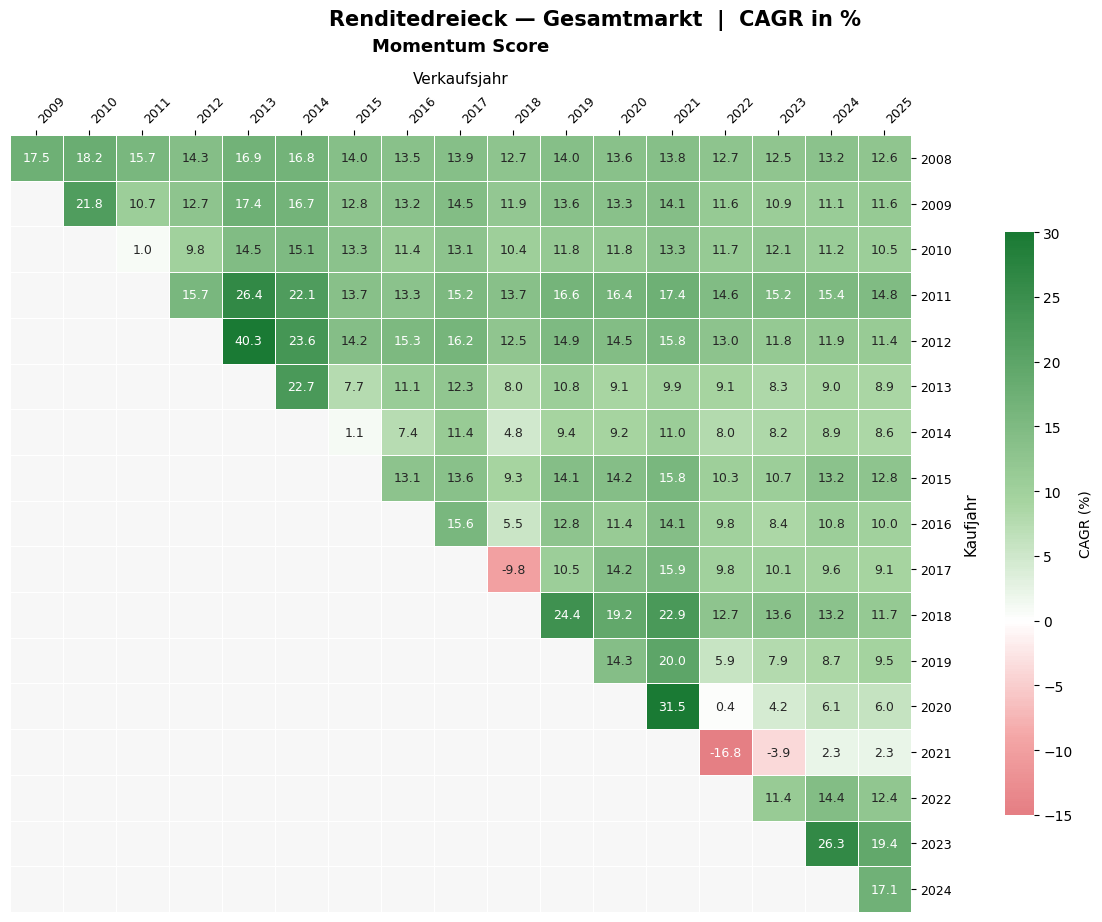

In [12]:
from backtest.renditedreieck import plot_renditedreieck
df_dd = df_strategies.drop(labels=["sector"], axis=1).groupby(by=["buyyear", "sellyear","strategy"], as_index=False).median()
df_bm = df_benchmark_raw.copy()

df_dd["sector"] = "Gesamtmarkt"
df_bm["sector"] = "Gesamtmarkt"


save_path= "backtest/attachments"

plot_renditedreieck(df_dd, "Gesamtmarkt", "momentum_score", label="Momentum Score", save_path=save_path)


Gespeichert: backtest/attachments/gesamtmarkt/value_score_Renditedreieck.png


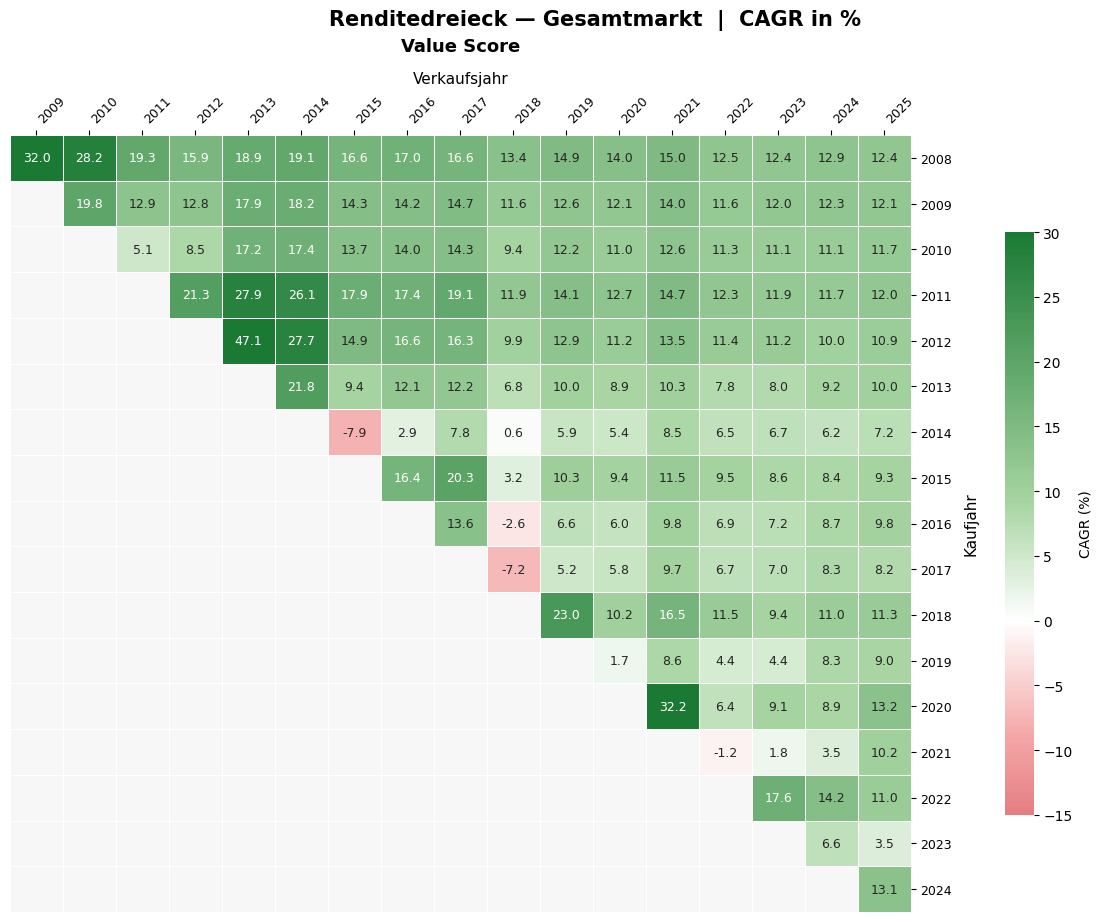

In [13]:
plot_renditedreieck(df_dd, "Gesamtmarkt", "value_score", label="Value Score", save_path=save_path)

In [14]:
df_bm

,buyyear,sellyear,index,rendite,strategy,horizon,sector
0,2008,2009,SPXEW,43.26,passive_SPXEW,1,Gesamtmarkt
1,2008,2010,SPXEW,31.01,passive_SPXEW,2,Gesamtmarkt
2,2008,2011,SPXEW,18.96,passive_SPXEW,3,Gesamtmarkt
3,2008,2012,SPXEW,18.03,passive_SPXEW,4,Gesamtmarkt
4,2008,2013,SPXEW,20.99,passive_SPXEW,5,Gesamtmarkt
...,...,...,...,...,...,...,...
301,2022,2024,GSPC,23.77,passive_GSPC,2,Gesamtmarkt
302,2022,2025,GSPC,21.26,passive_GSPC,3,Gesamtmarkt
303,2023,2024,GSPC,23.31,passive_GSPC,1,Gesamtmarkt
304,2023,2025,GSPC,19.80,passive_GSPC,2,Gesamtmarkt


Gespeichert: backtest/attachments/gesamtmarkt/passive_SPXEW_Renditedreieck.png


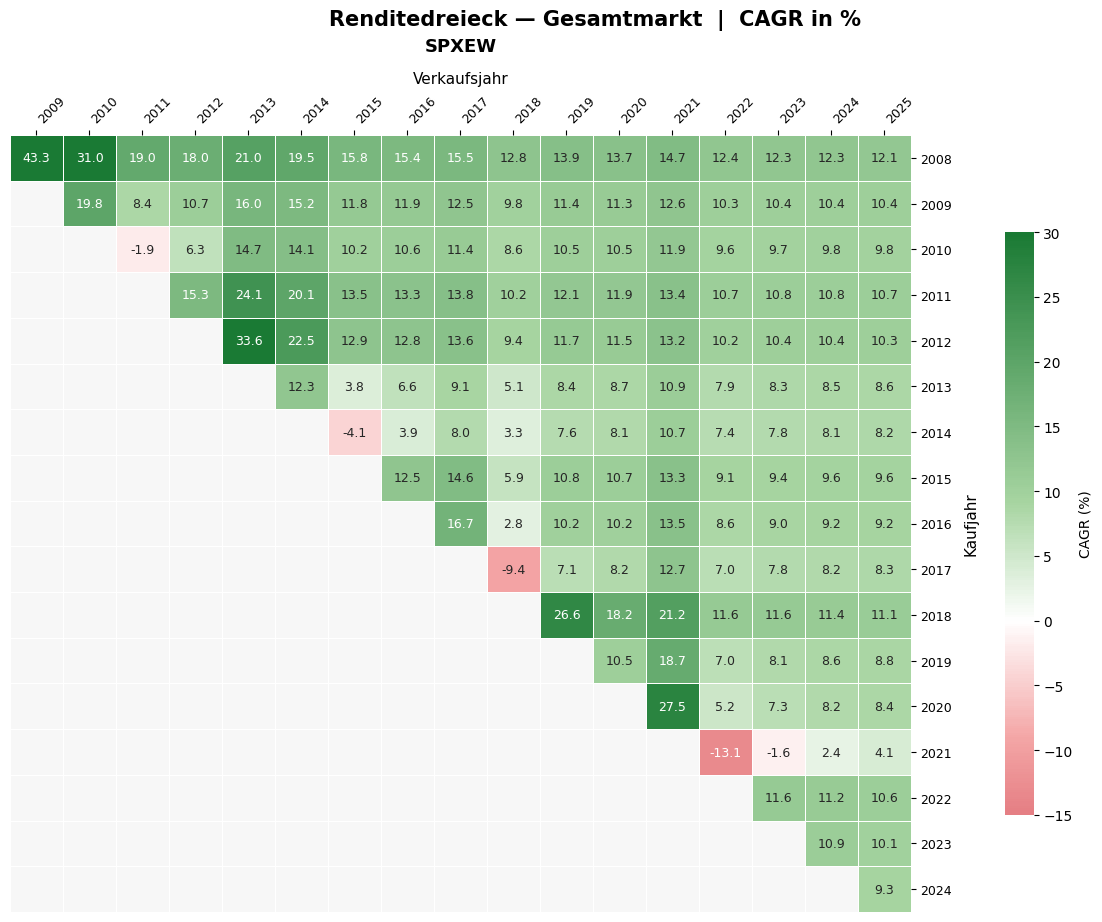

In [15]:
plot_renditedreieck(df_bm, "Gesamtmarkt", "passive_SPXEW", label="SPXEW", save_path=save_path)

Gespeichert: backtest/attachments/gesamtmarkt/passive_GSPC_Renditedreieck.png


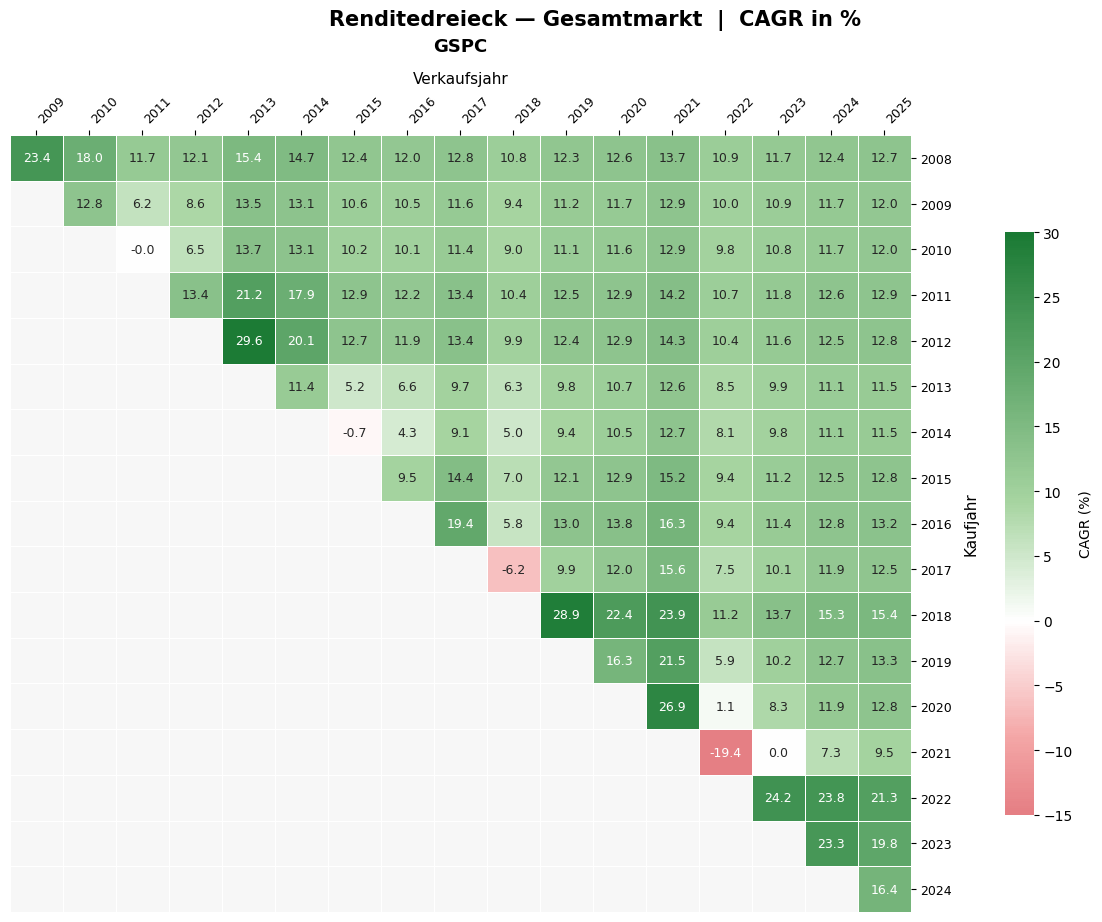

In [16]:
plot_renditedreieck(df_bm, "Gesamtmarkt", "passive_GSPC", label="GSPC", save_path=save_path)